# Pi output-calibration plotter

Ported from `PX4_Gazebo/notebooks/plotter_output_calibration.ipynb` (SITL) for the
Raspberry Pi / QTM mocap hardware pipeline. Reuses `derive_pi_cal.py`'s GT-flow
math and gap/outlier/KF handling directly (no duplicated math) so this notebook
and `derive_pi_cal.py` can never silently drift apart.

Sections:
- Currently-applied sensor_cal matrices (+ camera mount rotation)
- Ground truth (QTM -> body-FRD, V-frame)
- Calibrated flow/feature vs GT + quality metrics
- Telemetry (FC odometry) vs GT
- **Validating the IBVS optical-flow equation in the VIRTUAL frame (LHS vs RHS)**


In [32]:
import os, sys, types, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter as sgf
from scipy.interpolate import interp1d

# qtm (Qualisys SDK) and picamera2 are Pi-only hardware packages, not
# installed here - stub qtm so mocaptools (needed transitively to unpickle
# Ground_Truth.npy's Pose/PoseData objects) imports cleanly; we never open a
# live QTM connection from this notebook, only read recorded .npy files.
sys.modules.setdefault("qtm", types.ModuleType("qtm"))

SCRIPTS_DIR = os.path.abspath(os.path.join("..", "scripts"))
sys.path.insert(0, SCRIPTS_DIR)
import derive_pi_cal as DPC
import img_geometry as IG   # pure math (R_CAM_TO_BODY, camera intrinsics) - no hardware deps

CAL_DIR = os.path.abspath(os.path.join("..", "Test_Data", "Calibration", "Output"))

# Sorted by directory MTIME, not the folder name string - these folders are
# named "<Weekday> <Mon> <DD> <HH-MM-SS> <YYYY>" (time.ctime()-derived), and
# weekday names do not sort alphabetically in date order ("Sat" < "Sun" but
# also "Sat" < "Thu"/"Tue"/"Wed") - a plain string sort() silently picked an
# ARBITRARY run as "most recent", not the actual most recent one (found
# 2026-07-26 while cleaning up old runs - never actually verified before).
runs = sorted((d for d in glob.glob(os.path.join(CAL_DIR, "*")) if os.path.isdir(d)
               and os.path.exists(os.path.join(d, "Img_Data.npy"))),
              key=os.path.getmtime)
print(f"{len(runs)} run(s) found under {CAL_DIR}:")
for i, r in enumerate(runs):
    print(f"  [{i}] {os.path.basename(r)}")

# --- Pick a run directory. ---
RUN_IDX = 2   # default: most recent
run_dir = runs[RUN_IDX]
print(f"\nUsing: {run_dir}")


23 run(s) found under l:\Claude\Soft Landing\Hardware\Test_Data\Calibration\Output:
  [0] Sat Jul 25 21-48-14 2026
  [1] Sat Jul 25 21-50-47 2026
  [2] Sat Jul 25 21-51-59 2026
  [3] Sat Jul 25 21-52-41 2026
  [4] Sat Jul 25 21-53-12 2026
  [5] Sat Jul 25 21-55-15 2026
  [6] Sun Jul 26 22-02-04 2026
  [7] Sun Jul 26 22-07-54 2026
  [8] Sun Jul 26 22-07-54 2026_PureYaw
  [9] Sun Jul 26 22-15-47 2026
  [10] Sun Jul 26 22-15-47 2026_AirborneOnly
  [11] Sun Jul 26 22-02-04 2026_AirborneOnly
  [12] Sun Jul 26 22-07-54 2026_AirborneOnly
  [13] Sun Jul 26 22-20-17 2026
  [14] Sun Jul 26 22-20-17 2026_AirborneOnly
  [15] Sun Jul 26 22-23-04 2026
  [16] Sun Jul 26 22-23-04 2026_LowY
  [17] Sun Jul 26 22-23-04 2026_LowYZ
  [18] Sun Jul 26 22-58-53 2026
  [19] Sun Jul 26 23-01-25 2026
  [20] Sun Jul 26 23-02-13 2026
  [21] Sun Jul 26 23-05-48 2026
  [22] Sun Jul 26 23-06-20 2026

Using: l:\Claude\Soft Landing\Hardware\Test_Data\Calibration\Output\Sat Jul 25 21-51-59 2026


## Currently-applied sensor_cal matrices

Auto-loaded from the LIVE `img_data.py` on disk (not hardcoded), so this always
reflects whatever calibration is actually running on the Pi right now.

In [33]:
np.set_printoptions(precision=4, suppress=True, linewidth=120)

# _sensor_cal_hw / _sensor_cal_s are set inside IMG_PROCESSOR.__init__ in
# img_data.py, which we deliberately do NOT import here (it hard-imports
# picamera2 via imgstreamer.py, Pi-only - see img_geometry.py's docstring
# for why the pure-math pieces live there instead). Read the SOURCE FILE AS
# TEXT and extract the literal instead - img_data.py is the single source of
# truth for these calibration numbers; this just avoids executing the module.
IMG_DATA_PY = os.path.join(SCRIPTS_DIR, "img_data.py")
with open(IMG_DATA_PY, encoding="utf-8") as f:
    src = f.read()

# Finds `self.<varname> = np.array(...)` / `np.diag(...)` / `np.eye(...)` and
# returns the constructor-call text via PAREN-depth matching, scoped to right
# after THIS assignment's own '=' - not a bare text.find() for 'np.array('
# from that point on, which can (and did) match an unrelated np.array( call
# elsewhere later in the file instead of this one.
def _extract_np_array(varname, text):
    i = text.find(f"self.{varname}")
    if i < 0:
        return None
    eq = text.find("=", i)
    if eq < 0:
        return None
    candidates = [text.find(tok, eq) for tok in ("np.array(", "np.diag(", "np.eye(")]
    candidates = [c for c in candidates if c >= 0]
    if not candidates:
        return None
    start = min(candidates)
    paren_start = text.find("(", start)
    depth = 0
    end = paren_start
    for j, ch in enumerate(text[paren_start:], paren_start):
        if ch == "(":
            depth += 1
        elif ch == ")":
            depth -= 1
            if depth == 0:
                end = j + 1
                break
    return text[start:end]

print("_sensor_cal_hw:")
print(" ", _extract_np_array("_sensor_cal_hw", src))
print()
print("_sensor_cal_s:")
print(" ", _extract_np_array("_sensor_cal_s", src))
print()
print("R_CAM_TO_BODY (camera -> FC mount rotation, module-level constant):")
print(IG.R_CAM_TO_BODY)


_sensor_cal_hw:
  np.diag([1/6, 1/6, 1/6, 1, 1, 1])

_sensor_cal_s:
  np.diag([1/12, 1/12, 1, 1])

R_CAM_TO_BODY (camera -> FC mount rotation, module-level constant):
[[ 0.  1.  0.]
 [-1.  0.  0.]
 [ 0.  0.  1.]]


## Ground truth (QTM mocap -> body-FRD, gravity-leveled V-frame)

Reuses `derive_pi_cal.compute_gt_flow` directly - the frame transform (QTM FLU
-> FRD), gravity-leveled V-frame math, and depth regularization all live in
one place.

In [34]:
g = DPC.compute_gt_flow(run_dir)
t_g = g['t_g']
# Bare np.gradient on WRAPPED alpha spikes ~180 rad/s at any (-pi,pi] crossing
# (was silently wrong here - derive_one() fixed the same bug 2026-07-11 via
# unwrap+_robust_vel; this notebook cell had gone stale relative to it).
yaw_rate_g = DPC._robust_vel(np.unwrap(g['alpha'])[:, None], t_g)[:, 0]   # GT yaw rate, matches derive_one()'s G[:,5]
print(f'GT span: {t_g[-1]-t_g[0]:.1f} s   n samples: {len(t_g)}')
print(f'altitude range: {g["alt"].min():.2f} .. {g["alt"].max():.2f} m (FRD, +Z=down)')

GT span: 28.3 s   n samples: 4088
altitude range: 0.44 .. 1.52 m (FRD, +Z=down)


## Load image data (mount-rotation-corrected if available)

`derive_pi_cal.py`'s own convention: prefer `Img_Data_Recomputed.npy`
(`recompute_raw_flow.py` output, reflects `img_data.py`'s CURRENT
`_getVirtualPts` math including the camera mount-rotation fix) over the raw
`Img_Data.npy` logged at capture time by whatever code was live then.

In [35]:
recomputed_path = os.path.join(run_dir, "Img_Data_Recomputed.npy")
if os.path.exists(recomputed_path):
    img = np.load(recomputed_path, allow_pickle=True).item()
    print("using Img_Data_Recomputed.npy (mount-rotation-corrected)")
else:
    img = np.load(os.path.join(run_dir, "Img_Data.npy"), allow_pickle=True).item()
    print("using Img_Data.npy (raw capture-time log - run recompute_raw_flow.py for the corrected version)")

t_i = np.asarray(img["Time"], float)
raw_flow = np.asarray(img["Opt Flow Ang Vel"], float)
raw_feat = np.asarray(img["Feature Params"], float)
n = min(len(t_i), len(raw_flow), len(raw_feat))
t_i, raw_flow, raw_feat = t_i[:n], raw_flow[:n], raw_feat[:n]

raw_flow = DPC.reject_outliers(raw_flow, label="flow")
raw_feat = DPC.reject_outliers(raw_feat, label="feature")
raw_flow_kf = DPC.kf_filter_causal(raw_flow, t_i, DPC.FLOW_KF_Q, DPC.FLOW_KF_R)
raw_feat_kf = DPC.kf_filter_causal(raw_feat, t_i, DPC.FEAT_KF_Q, DPC.FEAT_KF_R)

# Parse the live cal matrices (cell above) into real arrays, then apply to the
# KF output - exactly what getOptFlowAngVel()/getImgFeatureParam() return at
# runtime.
_ns = {"np": np}
exec(f"_hw = {_extract_np_array('_sensor_cal_hw', src)}", _ns)
exec(f"_s  = {_extract_np_array('_sensor_cal_s', src)}", _ns)
sensor_cal_hw, sensor_cal_s = _ns["_hw"], _ns["_s"]

cal_flow = raw_flow_kf @ sensor_cal_hw.T
cal_feat = raw_feat_kf.copy()
cal_feat[:, :2] = raw_feat_kf[:, :2] @ sensor_cal_s[:2, :2].T

raw_flow_g = g["align"](t_i, raw_flow_kf)
cal_flow_g = g["align"](t_i, cal_flow)
raw_feat_g = g["align"](t_i, raw_feat_kf)
cal_feat_g = g["align"](t_i, cal_feat)
gok = g["gap_mask"](t_i, DPC.GAP_EXCLUDE_S)
print(f"{gok.sum()}/{len(gok)} GT-grid samples inside a trustworthy (non-gap) bracket")


using Img_Data.npy (raw capture-time log - run recompute_raw_flow.py for the corrected version)
  outlier guard (flow): 25 sample(s) rejected (Hampel filter, window=7, k=5.0)
  outlier guard (feature): 26 sample(s) rejected (Hampel filter, window=7, k=5.0)
4027/4088 GT-grid samples inside a trustworthy (non-gap) bracket


## Calibrated flow & feature vs GT + quality metrics

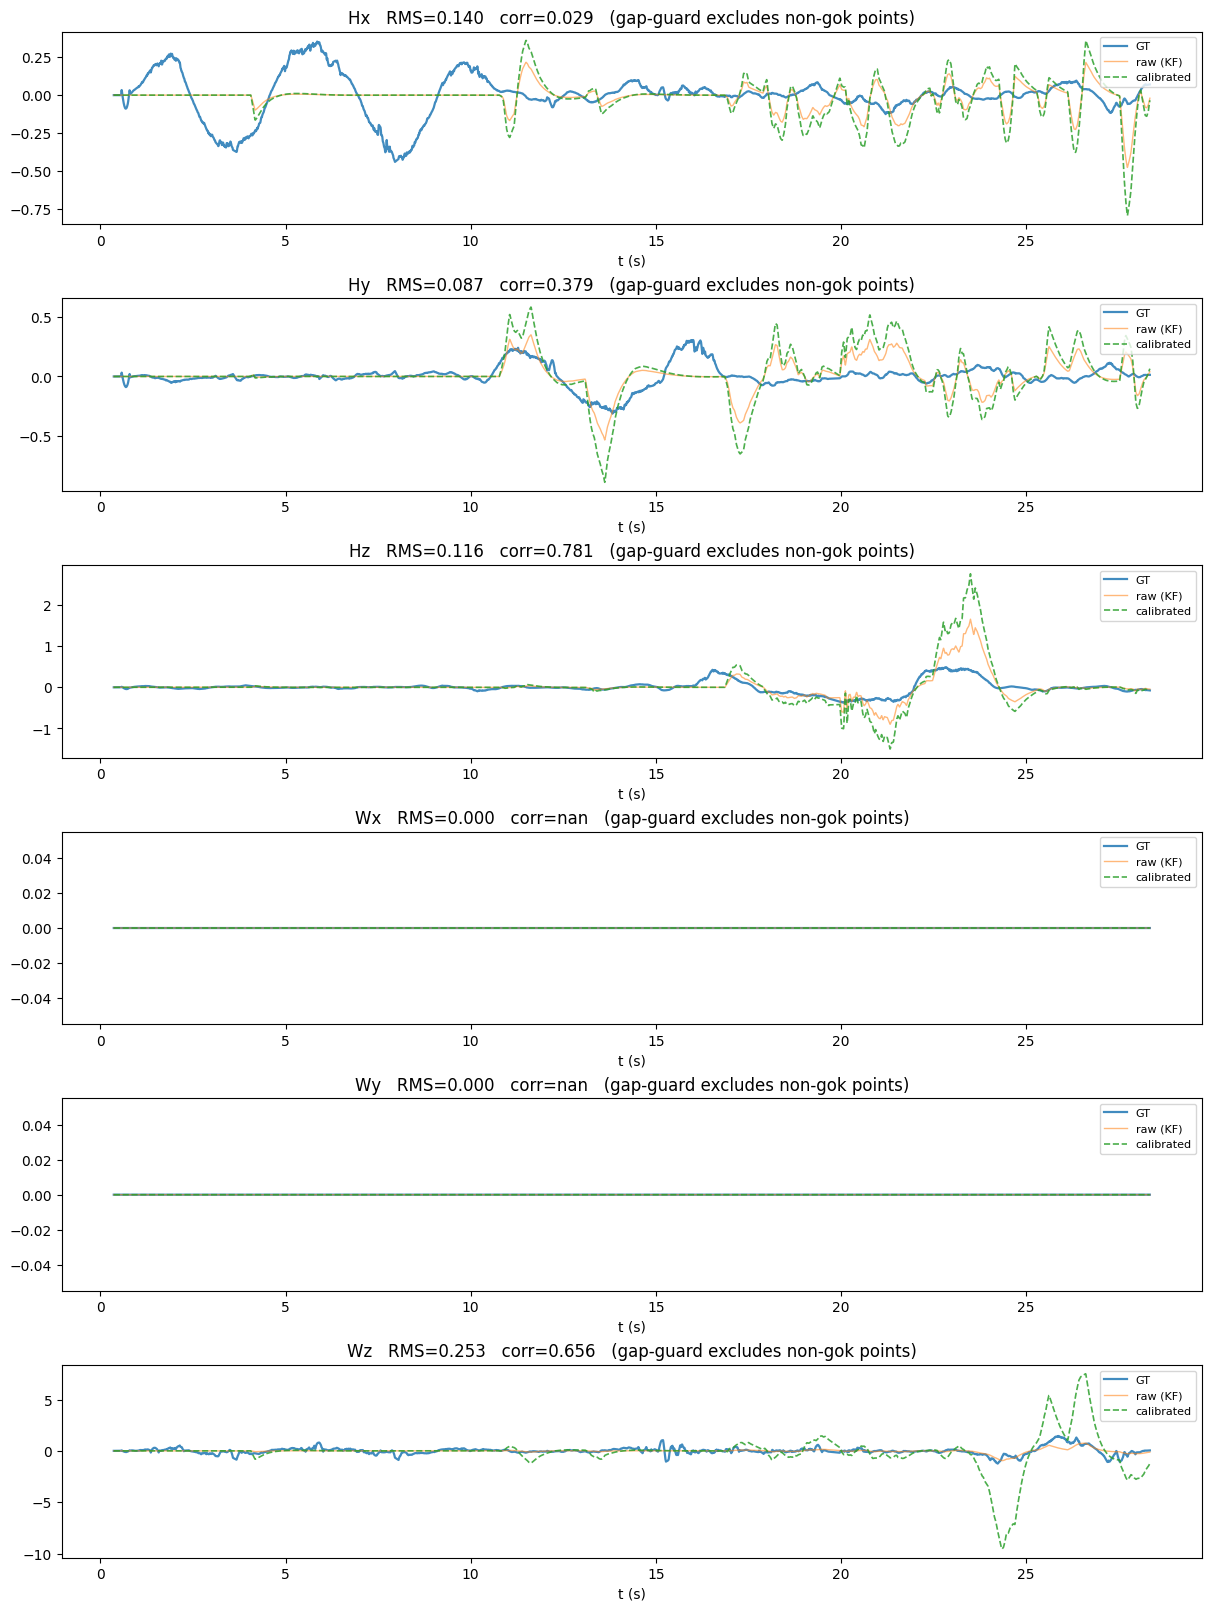

In [41]:
LAB = DPC.LAB   # ['Hx','Hy','Hz','Wx','Wy','Wz']
G = np.column_stack([g['V_h_g'], np.zeros((len(yaw_rate_g), 2)), yaw_rate_g])

fig, axes = plt.subplots(6, 1, figsize=(12, 16), constrained_layout=True)
for k, ax in enumerate(axes):
    m = gok & np.isfinite(G[:, k]) & np.isfinite(cal_flow_g[:, k])
    ax.plot(t_g[m], G[m, k], label='GT', linewidth=1.6, alpha=0.85)
    ax.plot(t_g[m], raw_flow_g[m, k], label='raw (KF)', linewidth=1.0, alpha=0.55)
    ax.plot(t_g[m], cal_flow_g[m, k], label='calibrated', linewidth=1.2, alpha=0.85, linestyle='--')
    if m.sum() > 5:
        rms = float(np.sqrt(np.mean((G[m, k] - cal_flow_g[m, k]) ** 2)))
        corr = float(np.corrcoef(G[m, k], cal_flow_g[m, k])[0, 1]) if np.std(cal_flow_g[m, k]) > 1e-9 else np.nan
        ax.set_title(f'{LAB[k]}   RMS={rms:.3f}   corr={corr:.3f}   (gap-guard excludes non-gok points)')
    else:
        ax.set_title(f'{LAB[k]}  (too few trustworthy samples)')
    ax.set_xlabel('t (s)'); ax.legend(loc='upper right', fontsize=8)
plt.show()

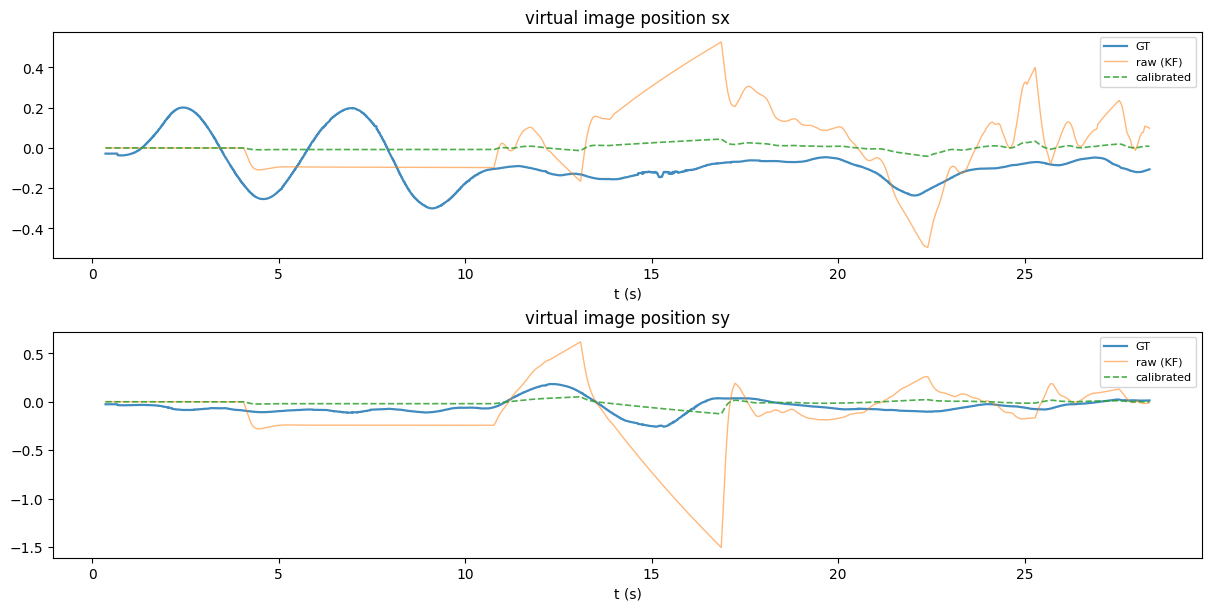

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
gs = g['V_s_g']
for k, (ax, lab) in enumerate(zip(axes, ['sx', 'sy'])):
    m = gok & np.isfinite(gs[:, k]) & np.isfinite(cal_feat_g[:, k])
    ax.plot(t_g[m], gs[m, k], label='GT', linewidth=1.6, alpha=0.85)
    ax.plot(t_g[m], raw_feat_g[m, k], label='raw (KF)', linewidth=1.0, alpha=0.55)
    ax.plot(t_g[m], cal_feat_g[m, k], label='calibrated', linewidth=1.2, alpha=0.85, linestyle='--')
    ax.set_title(f'virtual image position {lab}'); ax.set_xlabel('t (s)'); ax.legend(fontsize=8)
plt.show()

## Telemetry (FC odometry) vs GT

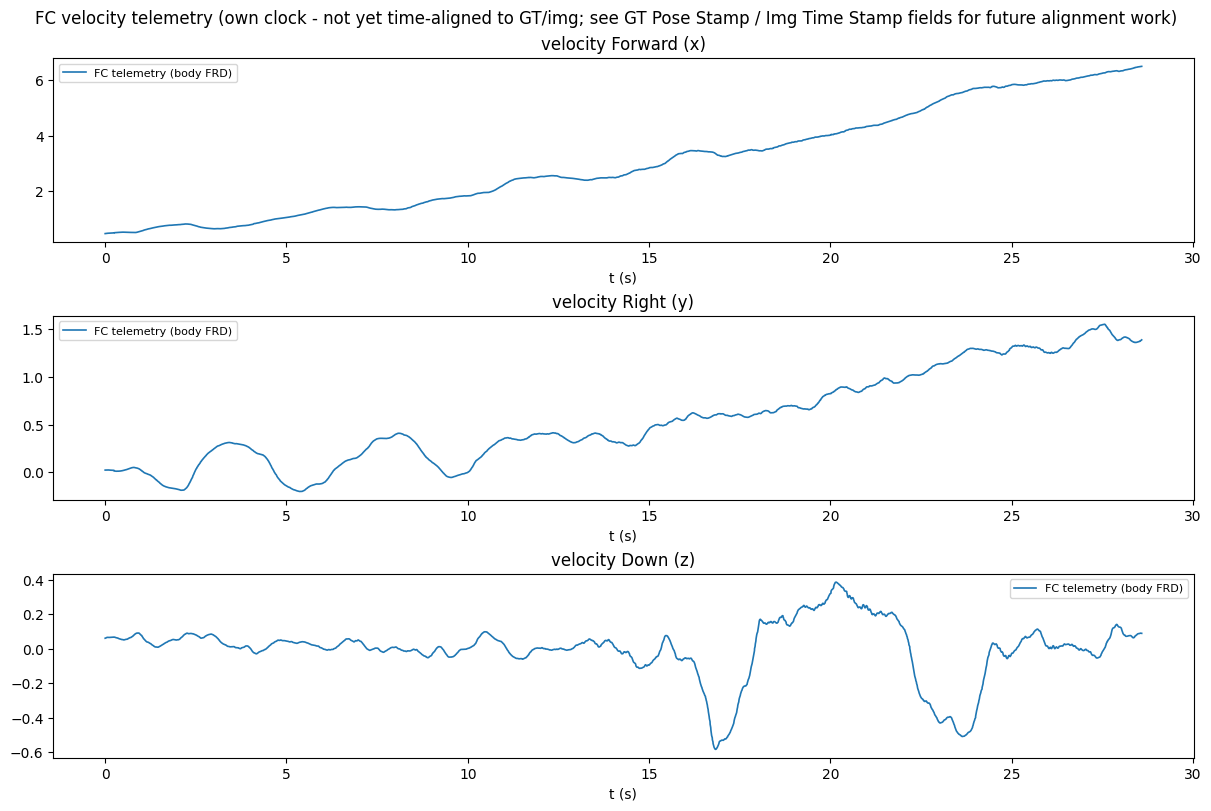

In [38]:
tel_path = os.path.join(run_dir, 'Telemetry_Data.npy')
if os.path.exists(tel_path):
    tel = np.load(tel_path, allow_pickle=True).item()
    t_tel = np.asarray(tel['Odometry Timestamp'], float)
    pos_body = np.array([[p.x_m, p.y_m, p.z_m] for p in tel['Position Body'] if p is not None])
    vel_body = np.array([[v.x_m_s, v.y_m_s, v.z_m_s] for v in tel['Velocity Body'] if v is not None])
    n_tel = min(len(t_tel), len(pos_body), len(vel_body))
    t_tel, pos_body, vel_body = t_tel[:n_tel], pos_body[:n_tel], vel_body[:n_tel]

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), constrained_layout=True)
    FRD_LBL = ['Forward (x)', 'Right (y)', 'Down (z)']
    for k, ax in enumerate(axes):
        ax.plot(t_tel - t_tel[0], vel_body[:, k], label='FC telemetry (body FRD)', linewidth=1.2)
        ax.set_title(f'velocity {FRD_LBL[k]}'); ax.set_xlabel('t (s)'); ax.legend(fontsize=8)
    plt.suptitle('FC velocity telemetry (own clock - not yet time-aligned to GT/img; '
                  'see GT Pose Stamp / Img Time Stamp fields for future alignment work)')
    plt.show()
else:
    print('no Telemetry_Data.npy in this run - skipping')

## Validating the IBVS optical-flow equation in the VIRTUAL frame (LHS vs RHS)

For each ArUco corner (virtual image position $s_i = (x_i, y_i)$), the IBVS
interaction matrix predicts the **optical flow** $\dot{s}_i$ from the **virtual
image velocity** $h$ and **angular velocity** $w$:

$$\dot{s}_i \;=\; L(s_i) \cdot \begin{bmatrix} h \\ w \end{bmatrix}$$

Validated **in the gravity-leveled virtual (V) frame** - the frame `img_data.py`
actually solves $[h;w]$ in (`A`/`Y` in `_optFlowAngVel` are built from
`V_dense = _getVirtualPts(...)`, which now includes the camera mount-rotation
fix `R_CAM_TO_BODY`). Ported directly from
`PX4_Gazebo/notebooks/plotter_output_calibration.ipynb` cells 46-48 (SITL),
same equation, same `L(s)` as `img_data.py::_fill_A` /
`MATLAB/.../visualControl_IBVS_adaptive.m`.

- **LHS** = measured optical flow: frame-to-frame **virtual**-corner velocity
  - $(s_i^{t+1}-s_i^{t})\cdot\text{fps}$. Exactly `(V_nP1-V_nP0)*fps` from the
  runtime lstsq (`Y` in `_optFlowAngVel`).
- **RHS** = predicted: $L(s_i)\cdot[h_V; w_V]$ using V-frame GT `h = V_h_g`,
  `w = [0, 0, yaw_rate_g]` (V-frame leveling removes body roll/pitch - only yaw
  survives), interpolated to image timestamps.

Requires `Img_Data_Recomputed.npy`'s `Virtual Feature Pts` (mount-rotation-
corrected V-frame corners, `recompute_raw_flow.py`) - the corrected LHS side.
A pre-fix `Img_Data.npy` would silently validate the OLD, wrong pipeline
against itself (LHS and RHS both built from the same buggy `_getVirtualPts`),
which isn't a meaningful check.

In [39]:
if 'Virtual Feature Pts' not in img:
    print('This run has no Virtual Feature Pts (raw Img_Data.npy, or an older '
          'recompute_raw_flow.py) - run recompute_raw_flow.py first.')
else:
    vfeat_pairs = img['Virtual Feature Pts'][:n]
    valid_idx = [i for i, p in enumerate(vfeat_pairs) if p is not None]
    # t_i (img['Time']) is ABSOLUTE perf_counter(); t_g is RELATIVE to
    # Start Time (see compute_gt_flow's own docstring) - without this
    # subtraction interp1d's fill_value=0.0 silently zero-fills the ENTIRE
    # RHS (every t_i_v falls outside t_g's [0, span] range), which is
    # exactly what was happening before this fix (RHS std=0, all-NaN
    # correlation) - not a data-quality issue, a units mismatch.
    t_i_v = t_i[valid_idx] - g['start_time']
    fps_v = np.asarray(img['FPS'], float)[valid_idx]
    v_old = np.array([np.asarray(vfeat_pairs[i][0], float) for i in valid_idx])   # (n_v, 4, 2)
    v_new = np.array([np.asarray(vfeat_pairs[i][1], float) for i in valid_idx])
    n_v = len(valid_idx)

    # V-frame GT [h; w]: leveling removes roll/pitch -> only yaw (w_z) survives.
    y_w_V = np.hstack([g['V_h_g'], np.zeros((len(t_g), 2)), yaw_rate_g[:, None]])
    V_input_at_img = np.zeros((n_v, 6))
    for k in range(6):
        f_intp = interp1d(t_g, y_w_V[:, k], bounds_error=False, fill_value=0.0)
        V_input_at_img[:, k] = f_intp(t_i_v)

    RHS = np.zeros((n_v, 4, 2))
    for f_idx in range(n_v):
        yw = V_input_at_img[f_idx]
        for i_corner in range(4):
            x, y = v_new[f_idx, i_corner]
            L = np.array([
                [1, 0, -x, -x*y,      1+x**2, -y],
                [0, 1, -y, -(1+y**2), x*y,     x],
            ])
            RHS[f_idx, i_corner] = L @ yw

    LHS = (v_new - v_old) * fps_v[:, None, None]

    W = 11
    if n_v > W:
        LHS = sgf(LHS.reshape(n_v, -1), W, 2, axis=0).reshape(n_v, 4, 2)
        RHS = sgf(RHS.reshape(n_v, -1), W, 2, axis=0).reshape(n_v, 4, 2)

    print(f'LHS / RHS shapes: {LHS.shape} / {RHS.shape}   n = {n_v}')
    print('Frame: VIRTUAL (gravity-leveled, mount-rotation-corrected) - matches '
          'img_data.py _getVirtualPts + lstsq')

LHS / RHS shapes: (759, 4, 2) / (759, 4, 2)   n = 759
Frame: VIRTUAL (gravity-leveled, mount-rotation-corrected) - matches img_data.py _getVirtualPts + lstsq


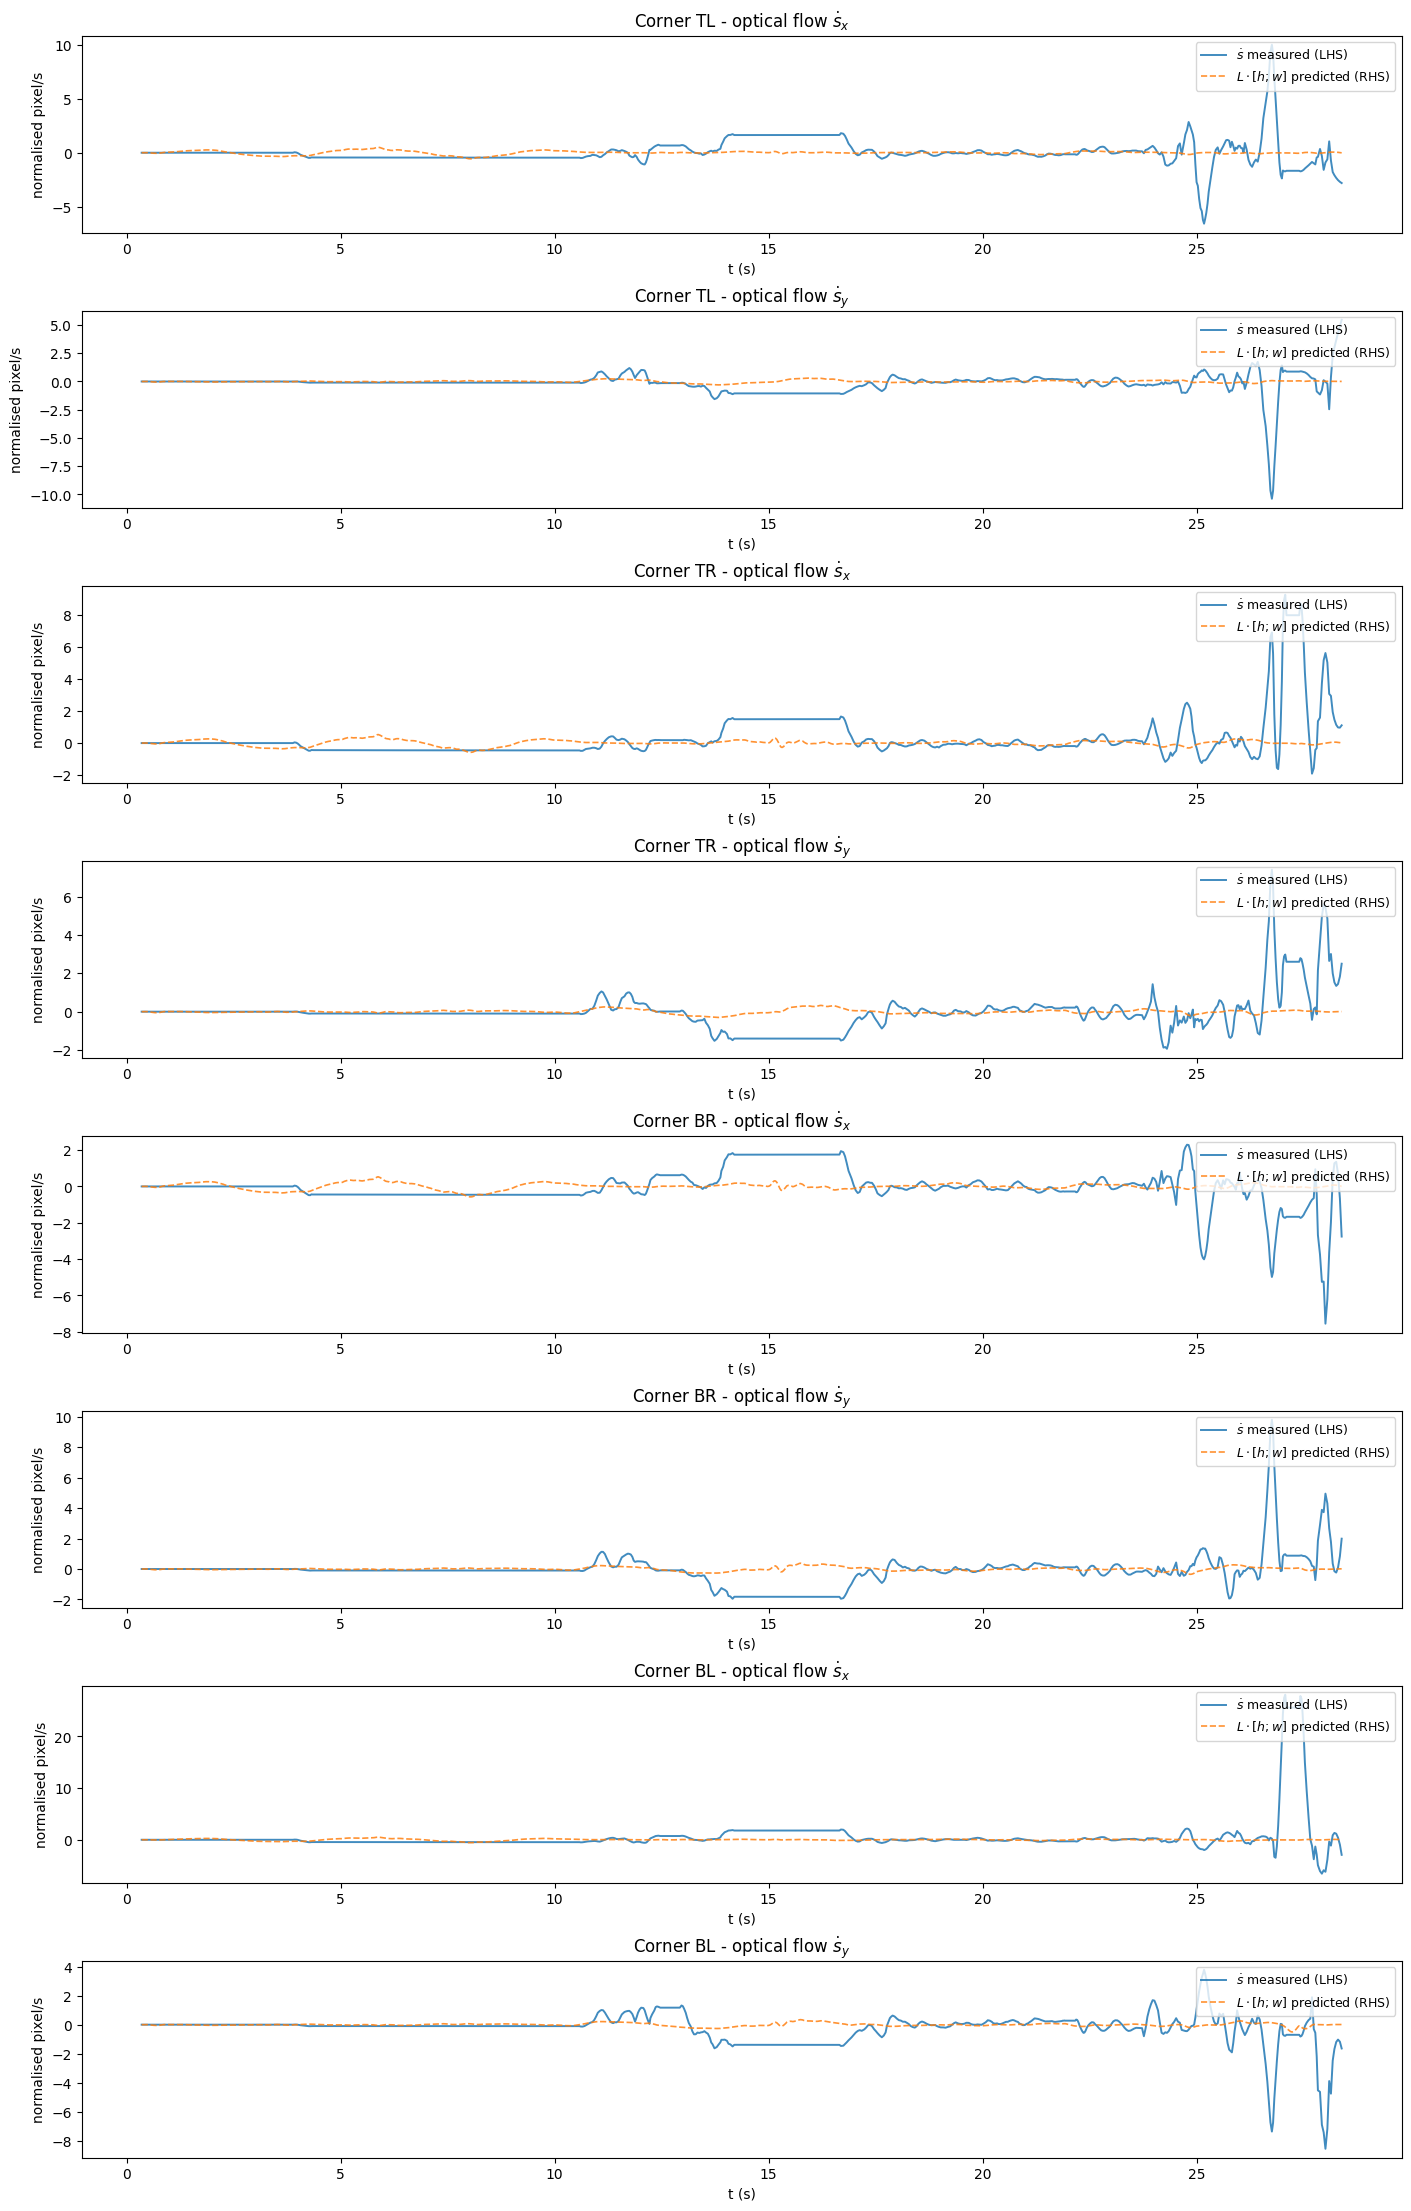

per-panel LHS/RHS correlation: [-0.011 -0.04  -0.037  0.027 -0.015 -0.072 -0.045 -0.108]


In [40]:
if 'Virtual Feature Pts' in img and n_v > 0:
    fig, axes = plt.subplots(8, 1, figsize=(14, 22), constrained_layout=True)
    labels_corner = ['TL', 'TR', 'BR', 'BL']
    labels_axis = ['x', 'y']
    for k, ax in enumerate(axes):
        corner = k // 2
        axis = k % 2
        ax.plot(t_i_v, LHS[:, corner, axis], label=r'$\dot{s}$ measured (LHS)', linewidth=1.4, alpha=0.85)
        ax.plot(t_i_v, RHS[:, corner, axis], label=r'$L\cdot[h;w]$ predicted (RHS)',
                linewidth=1.2, alpha=0.85, linestyle='--')
        ax.set_title(f'Corner {labels_corner[corner]} - optical flow '
                      f'$\dot{{s}}_{{{labels_axis[axis]}}}$')
        ax.set_xlabel('t (s)'); ax.set_ylabel('normalised pixel/s')
        ax.legend(loc='upper right', fontsize=9)
    plt.show()

    lhs_flat = LHS.reshape(n_v, -1)
    rhs_flat = RHS.reshape(n_v, -1)
    corr = np.array([np.corrcoef(lhs_flat[:, k], rhs_flat[:, k])[0, 1]
                      if np.std(rhs_flat[:, k]) > 1e-9 else np.nan for k in range(8)])
    print('per-panel LHS/RHS correlation:', np.round(corr, 3))

**Interpretation, same caveat as SITL:** residual here reflects the runtime's
own (noisy) attitude estimate leveling each frame - it is NOT expected to be a
perfect match even with a correct calibration. Low/negative correlation across
*most* panels (rather than a few) would indicate a genuine geometry error
(mount rotation, corner ordering, or interaction-matrix sign) - re-check
`R_CAM_TO_BODY` and `_fill_A` before trusting any downstream calibration fit.